In [ ]:
import pickle
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("📂 Loading data preprocessing...")
with open('eeg_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"✅ Data berhasil dimuat!")
print(f"   Jumlah data training: {len(X_train)} (70%)")
print(f"   Jumlah data testing: {len(X_test)} (30%)")
print(f"   Jumlah fitur: {X_train.shape[1]}")

In [ ]:
print("\n🚀 Mulai training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1  # Pakai semua CPU core
)
rf_model.fit(X_train, y_train)

print(rf_model.fit(X_train, y_train))


In [ ]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Random Forest: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [ ]:
print("\n📋 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

In [ ]:
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Random Forest\nAkurasi: {accuracy:.2%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300)
print("\n✅ Confusion matrix disimpan ke 'confusion_matrix_rf.png'")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

print("\n📊 Top 20 Feature Importance:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#e74c3c')
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300)
print("\n✅ Feature importance disimpan ke 'feature_importance_rf.png'")
plt.show()

In [ ]:
model_data = {
    'model': rf_model,
    'accuracy': accuracy,
    'feature_names': X_train.columns.tolist(),
    'train_size': len(X_train),
    'test_size': len(X_test)
}

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n✅ Model Random Forest berhasil disimpan ke 'random_forest_model.pkl'")
print("\n🎉 Training selesai!")

In [ ]:
from sklearn.model_selection import cross_val_score

print("\n🚀 Cross-Validation (5-Fold)...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Std Dev: {cv_scores.std():.4f}")

In [ ]:
with open('eeg_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X_test = data['X_test']
y_test = data['y_test']

# Load model
with open('random_forest_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

rf_model = model_data['model']

# Prediksi
y_pred = rf_model.predict(X_test)

# Buat DataFrame hasil
hasil = pd.DataFrame({
    'Index': range(len(y_test)),
    'True_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Status': ['✅ Benar' if true == pred else '❌ Salah' 
               for true, pred in zip(y_test.values, y_pred)]
})

# Tampilkan
print("="*70)
print("📊 HASIL PREDIKSI PER DATA")
print("="*70)
print(hasil.to_string(index=False))

# Summary
print("\n" + "="*70)
print("📈 RINGKASAN")
print("="*70)
total = len(hasil)
benar = (hasil['Status'] == '✅ Benar').sum()
salah = (hasil['Status'] == '❌ Salah').sum()

print(f"Total Data Test: {total}")
print(f"Prediksi Benar: {benar} ({benar/total*100:.2f}%)")
print(f"Prediksi Salah: {salah} ({salah/total*100:.2f}%)")


k fold 

📂 Loading data preprocessing...
✅ Data berhasil dimuat!
   Jumlah data training: 24
   Jumlah fitur: 70

🚀 K-FOLD CROSS-VALIDATION (K=5)


d:\eeg-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 Hasil Per Fold:
----------------------------------------------------------------------
Fold     Accuracy     Precision    Recall       F1-Score    
----------------------------------------------------------------------
Fold 1   0.6000       0.5833       0.6250       0.5417
Fold 2   1.0000       1.0000       1.0000       1.0000
Fold 3   0.6000       0.6250       0.6250       0.5833
Fold 4   1.0000       1.0000       1.0000       1.0000
Fold 5   1.0000       1.0000       1.0000       1.0000

📈 RINGKASAN HASIL K-FOLD CV

ACCURACY:
  Test  - Mean: 0.8400 (84.00%) | Std: 0.1960
  Train - Mean: 1.0000 (100.00%) | Std: 0.0000

PRECISION MACRO:
  Test  - Mean: 0.8417 (84.17%) | Std: 0.1944
  Train - Mean: 1.0000 (100.00%) | Std: 0.0000

RECALL MACRO:
  Test  - Mean: 0.8500 (85.00%) | Std: 0.1837
  Train - Mean: 1.0000 (100.00%) | Std: 0.0000

F1 MACRO:
  Test  - Mean: 0.8250 (82.50%) | Std: 0.2147
  Train - Mean: 1.0000 (100.00%) | Std: 0.0000

⚠️ CEK OVERFITTING
Training Accuracy:   1.0000

C:\Users\DELL LATITUDE 7280\AppData\Local\Temp\ipykernel_15340\2531082729.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score'])



✅ Visualisasi disimpan ke 'kfold_cv_results.png'


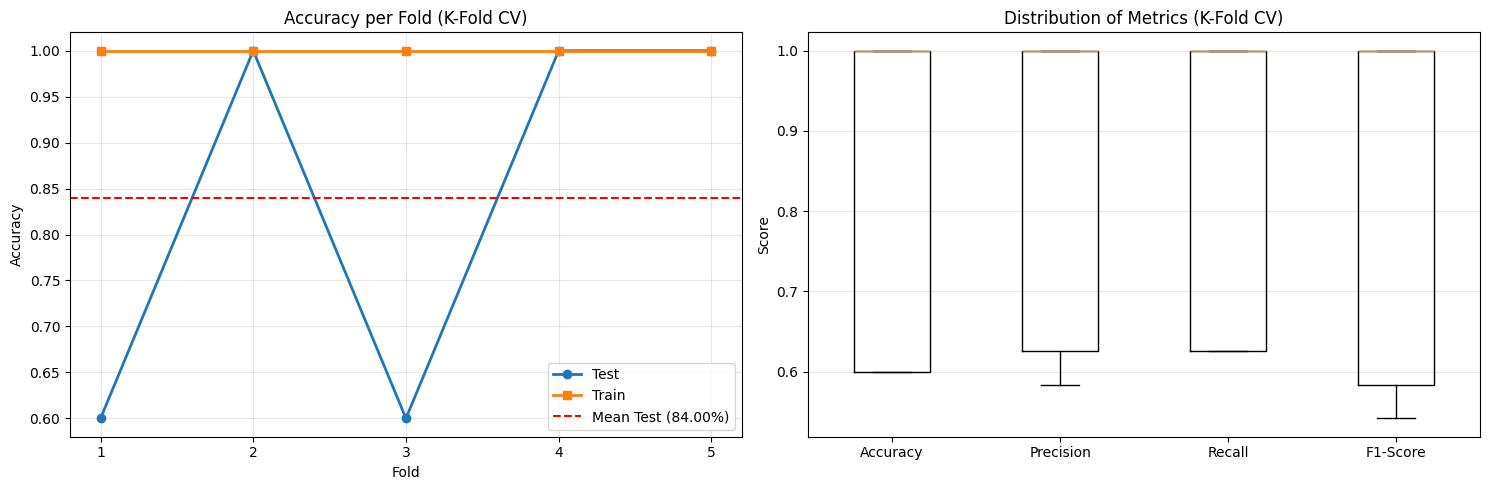


🚀 TRAINING MODEL FINAL (SEMUA DATA TRAINING)
✅ Model final berhasil dilatih!
🎯 Akurasi di Test Set: 0.8125 (81.25%)

✅ Hasil K-Fold CV disimpan ke 'random_forest_kfold_cv.pkl'

🎉 K-Fold Cross-Validation selesai!


In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ========================================
# 1. LOAD DATA PREPROCESSING
# ========================================
print("📂 Loading data preprocessing...")
with open('eeg_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']

print(f"✅ Data berhasil dimuat!")
print(f"   Jumlah data training: {len(X_train)}")
print(f"   Jumlah fitur: {X_train.shape[1]}")

# ========================================
# 2. K-FOLD CROSS-VALIDATION (K=5)
# ========================================
print("\n" + "="*70)
print("🚀 K-FOLD CROSS-VALIDATION (K=5)")
print("="*70)

# Setup K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Cross-validation dengan multiple metrics
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_results = cross_validate(
    rf_model, 
    X_train, 
    y_train, 
    cv=kfold, 
    scoring=scoring,
    return_train_score=True
)

# ========================================
# 3. TAMPILKAN HASIL PER FOLD
# ========================================
print("\n📊 Hasil Per Fold:")
print("-"*70)
print(f"{'Fold':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*70)

for i in range(5):
    print(f"Fold {i+1}   "
          f"{cv_results['test_accuracy'][i]:.4f}       "
          f"{cv_results['test_precision_macro'][i]:.4f}       "
          f"{cv_results['test_recall_macro'][i]:.4f}       "
          f"{cv_results['test_f1_macro'][i]:.4f}")

# ========================================
# 4. RATA-RATA & STANDARD DEVIASI
# ========================================
print("\n" + "="*70)
print("📈 RINGKASAN HASIL K-FOLD CV")
print("="*70)

metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
for metric in metrics:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test  - Mean: {test_scores.mean():.4f} ({test_scores.mean()*100:.2f}%) | Std: {test_scores.std():.4f}")
    print(f"  Train - Mean: {train_scores.mean():.4f} ({train_scores.mean()*100:.2f}%) | Std: {train_scores.std():.4f}")

# ========================================
# 5. CEK OVERFITTING
# ========================================
print("\n" + "="*70)
print("⚠️ CEK OVERFITTING")
print("="*70)

train_acc = cv_results['train_accuracy'].mean()
test_acc = cv_results['test_accuracy'].mean()
diff = train_acc - test_acc

print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Selisih (Gap):       {diff:.4f} ({diff*100:.2f}%)")

if diff > 0.1:
    print("❌ WARNING: Kemungkinan OVERFITTING! (Gap > 10%)")
    print("   Solusi: Kurangi kompleksitas model atau tambah data")
elif diff > 0.05:
    print("⚠️ PERHATIAN: Sedikit overfitting (Gap 5-10%)")
else:
    print("✅ BAGUS: Tidak ada overfitting signifikan")

# ========================================
# 6. VISUALISASI HASIL CV
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy per fold
fold_numbers = range(1, 6)
axes[0].plot(fold_numbers, cv_results['test_accuracy'], marker='o', label='Test', linewidth=2)
axes[0].plot(fold_numbers, cv_results['train_accuracy'], marker='s', label='Train', linewidth=2)
axes[0].axhline(y=test_acc, color='r', linestyle='--', label=f'Mean Test ({test_acc:.2%})')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy per Fold (K-Fold CV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(fold_numbers)

# Plot 2: Box plot semua metrics
metrics_data = [
    cv_results['test_accuracy'],
    cv_results['test_precision_macro'],
    cv_results['test_recall_macro'],
    cv_results['test_f1_macro']
]
axes[1].boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
axes[1].set_ylabel('Score')
axes[1].set_title('Distribution of Metrics (K-Fold CV)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('kfold_cv_results.png', dpi=300)
print("\n✅ Visualisasi disimpan ke 'kfold_cv_results.png'")
plt.show()

# ========================================
# 7. TRAINING FINAL MODEL
# ========================================
print("\n" + "="*70)
print("🚀 TRAINING MODEL FINAL (SEMUA DATA TRAINING)")
print("="*70)

rf_model_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_final.fit(X_train, y_train)

# Test di test set
X_test = data['X_test']
y_test = data['y_test']
y_pred = rf_model_final.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Model final berhasil dilatih!")
print(f"🎯 Akurasi di Test Set: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ========================================
# 8. SIMPAN HASIL CV
# ========================================
cv_summary = {
    'model': rf_model_final,
    'cv_results': cv_results,
    'mean_cv_accuracy': test_acc,
    'std_cv_accuracy': cv_results['test_accuracy'].std(),
    'test_set_accuracy': test_accuracy,
    'n_folds': 5
}

with open('random_forest_kfold_cv.pkl', 'wb') as f:
    pickle.dump(cv_summary, f)

print("\n✅ Hasil K-Fold CV disimpan ke 'random_forest_kfold_cv.pkl'")
print("\n🎉 K-Fold Cross-Validation selesai!")